### CS4423 - Networks
Anton Baykalov  
School of Mathematical and Statistical Sciences  
University of Galway  

[![Open in Binder](images/badge_logo.png)](https://mybinder.org/v2/gh/anton-baykalov/networks/HEAD)

https://mybinder.org/v2/gh/anton-baykalov/networks/HEAD

#### 5. Small Worlds

# Week 10, lecture 1: Watts-Strogatz model

* The fact that random networks tend to have low transitivity and clustering shows the need of a new kind of (random) network model
that is better at mimicking real world networks.

* One idea, developed by Watts and Strogatz in 1998, is to start with some **regular network** that
naturally has a **high clustering**, and then to randomly distort its edges, to introduce some **short paths**.

In [1]:
import networkx as nx
opts = { "with_labels": True, "node_color": 'y' }

## Circle Graphs

Idea: we can tweak a graph so that its transitivity and clustering increase by adding triangles. For example, we can do that to cycle graphs to obtain so-called circle graphs.

0.0
2.7777777777777777


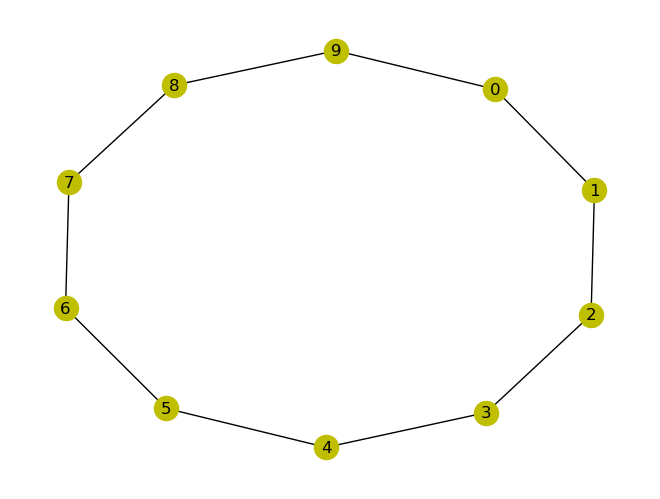

In [2]:
n = 10
G = nx.cycle_graph(n)
nx.draw(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))

0.5
1.6666666666666667


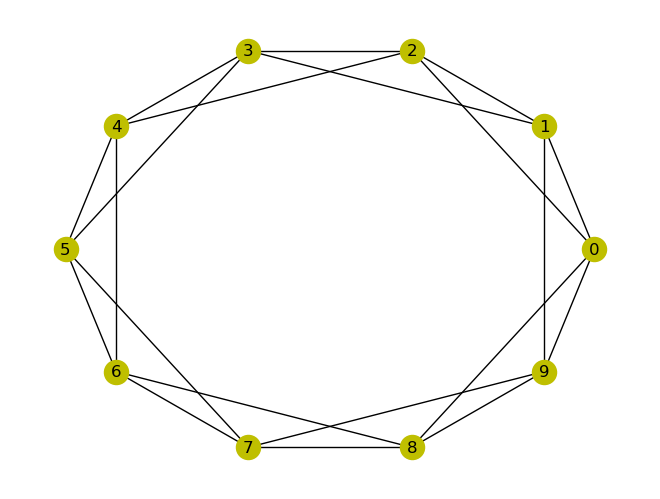

In [3]:
for v in G:
    G.add_edge(v, (v+2) % n)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))

Looks like we're going in the right direction: $L$ is getting smaller while $C$ is increasing. 

0.6
1.3333333333333333


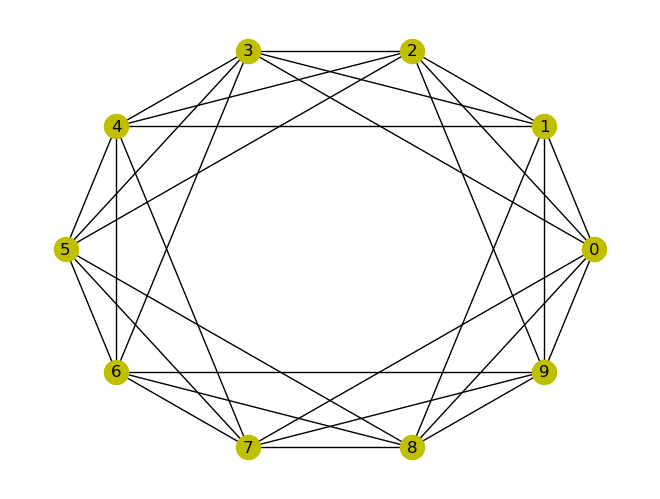

In [4]:
for v in G:
    G.add_edge(v, (v+3) % n)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))

**Definition (Circle Graph).** For $1 < d < n/2$, an $(n, d)$-**circle graph**
is obtained from a cycle on $n$ vertices by additionally linking each node
to all nodes that are not more than $d$ steps away on the cycle.


In [5]:
def circle_graph(n, d):
    G = nx.cycle_graph(n)
    for v in G:
        for o in range(2, d+1):
            G.add_edge(v, (v+o) % n)
    return G

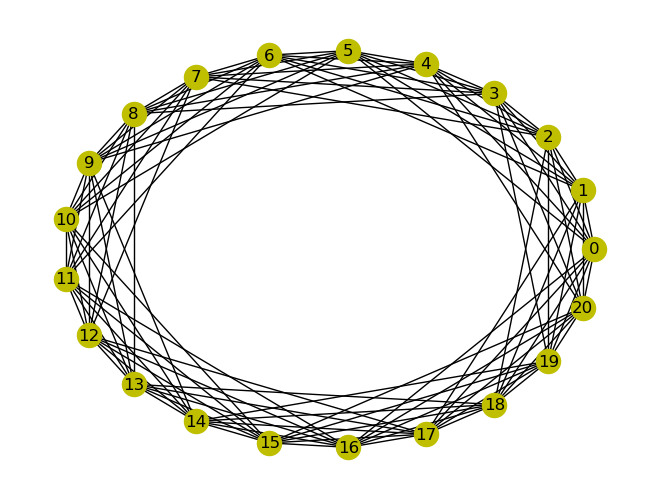

In [6]:
G = circle_graph(21, 5)
nx.draw_circular(G, **opts)

In [7]:
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))

0.6666666666666666
1.5


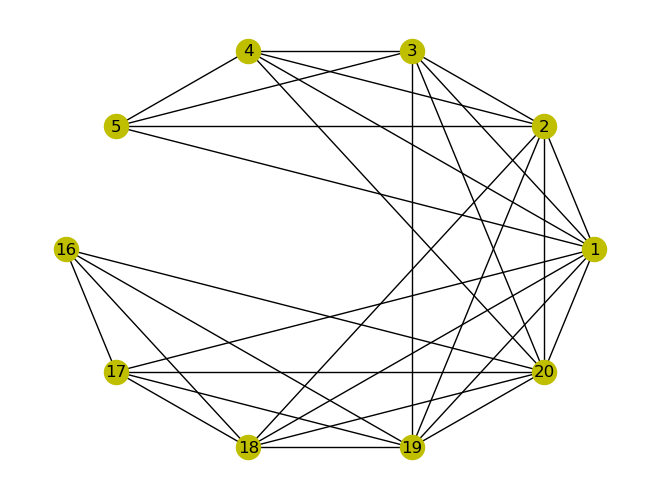

In [8]:
N = G.neighbors(0)
S = nx.subgraph(G, list(N))
nx.draw_circular(S, **opts)

In [9]:
S.degree()

DegreeView({1: 8, 2: 7, 3: 6, 4: 5, 5: 4, 16: 4, 17: 5, 18: 6, 19: 7, 20: 8})

In [10]:
S.size()

30

* An $(n, d)$-circle graph has $n$ nodes and $m = nd$ edges.

* Each node has degree $\frac{2m}{n} = 2d$.

* The social graph of each node has
$$ \frac{3}{2}d(d-1)$$ 
edges.

* The graph clustering coefficient of an $(n, d)$-circle graph is **independent of $n$**, and can be determined as
$$
C = \frac{3d - 3}{4d - 2} \to \frac34 \text{, as } d \to \infty.
$$
In particular:
$$
\begin{array}{l|rrrrr}
d & 1 & 2 & 3 & 4 & 5 \\ \hline
C & 0 & 0.5 & 0.6 & 0.643 & 0.667
\end{array}
$$

* However, things don't work as well when it comes to shortest paths (if we let $n\to \infty$). Indeed, the characteristic path length of an $(n, d)$-circle graph is
approximately
$$
L \approx \frac{n}{4d},
$$
growing linearly with $n$ (for fixed $d$).

In conclusion, such regular graphs have **high clustering** but **long shortest paths**,
hence $(n, d)$-circle graphs do not exhibit the small world behaviour.

## The Watts-Strogatz Model

The following modification of the circle graph was suggested by Duncan J. Watts and Steven Strogatz ([1998](https://en.wikipedia.org/wiki/Watts%E2%80%93Strogatz_model)). The idea is to introduce a probabilistic element to the graph, which results in "shortcuts" between the nodes and in a shortening of the characteristic path length.

**Definition (The WS Model).**
Let $1 < d < n/2$ and $0\leq p \leq 1$.  An $(n, d, p)$-WS graph $G = (X, E)$ is constructed from
an $(n, d)$-circle graph $G_0 = (X, E_0)$ by rewiring each of the edges in $E_0$ with probability $p$,
as follows:

1. visit the nodes $X = \{0, \dots, n{-}1\}$ in turn ('clockwise').

2. for each node $i \in X$ consider the $d$ edges connecting $i$ to $j$
in a clockwise sense ($j = i+1, \dots, i+d$).

3. With probability $p$, in the edge $(i, j)$ replace
$j$ by node $k \in X$ chosen uniformly at random, subject to
  * $k \neq i$, and
  * $(i, k)$ must not be an edge of $G$ already.

In [11]:
import random as rd
def ws_graph(n, d, p):
    G = circle_graph(n, d)
    for v in G:
        for o in range(1, d+1):
            if rd.random() < p:
                w = rd.randint(0,n-1)
                if w != v and not G.has_edge(v, w):
                    G.remove_edge(v, (v+o) % n)
                    G.add_edge(v, w)
    return G

0.3405238095238095
2.59265306122449
(50, 150)


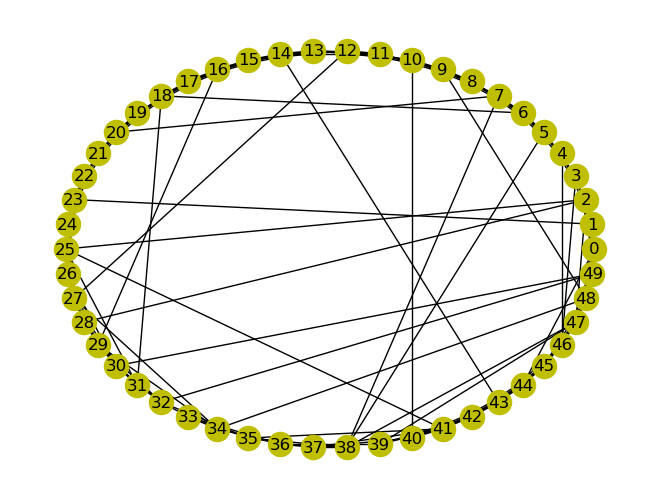

In [32]:
n, d = 50, 3
G = ws_graph(n, d, 0.2)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))
print((G.order(), G.size()))

0.3395238095238095
2.5616326530612246
(50, 150)


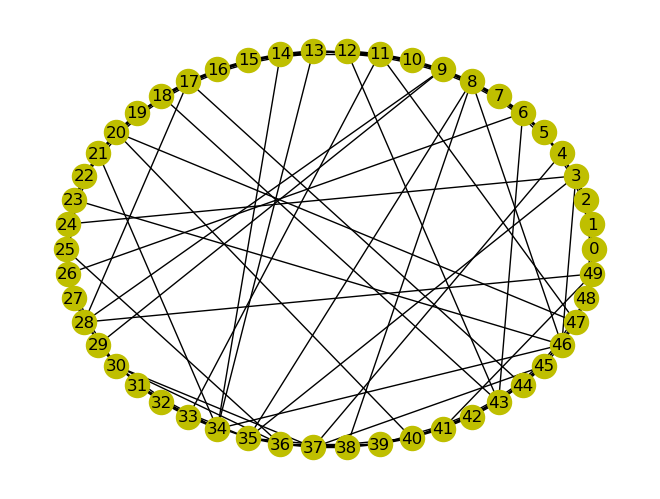

In [33]:
G = ws_graph(n, d, 0.2)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))
print((G.order(), G.size()))

0.20784126984126985
2.4114285714285715
(50, 150)


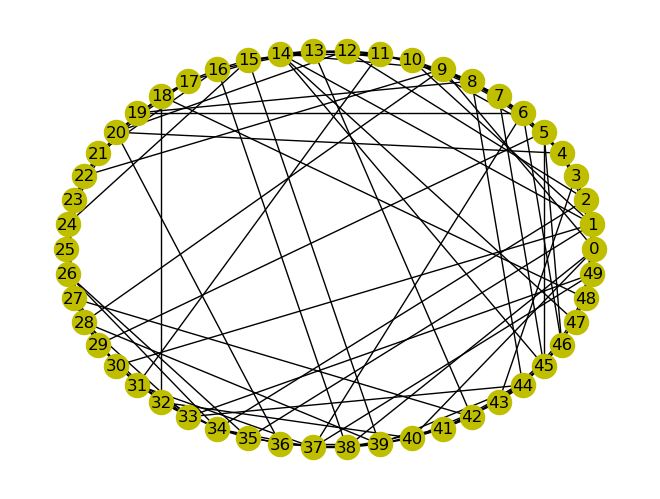

In [35]:
G = ws_graph(n, d, 0.3)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))
print((G.order(), G.size()))

0.11068253968253967
2.296326530612245
(50, 150)


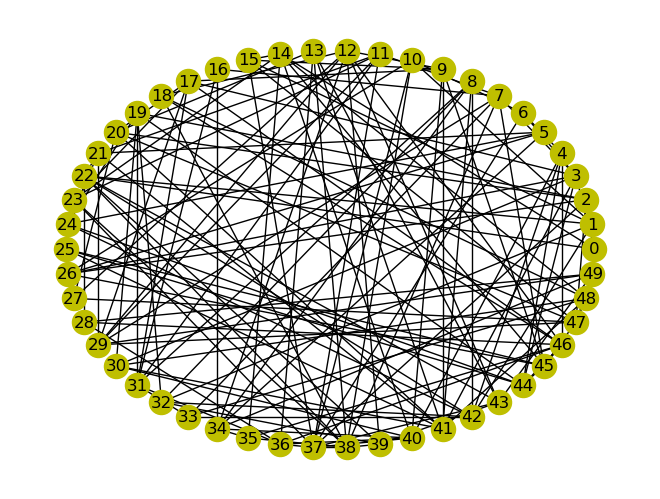

In [43]:
G = ws_graph(n, d, 1)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))
print((G.order(), G.size()))

A WS graph with parameters $(n, d, p)$ can be generated with the command `nx.watts_strogatz_graph(n, 2*d, p)`.

0.3709750566893424
1.8333333333333333


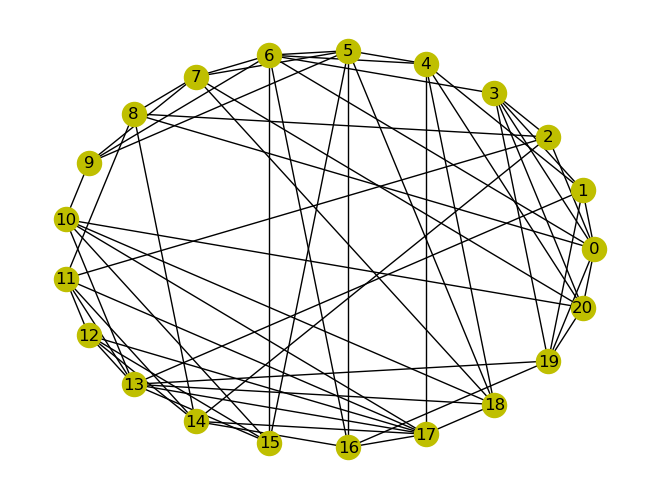

In [44]:
n, d = 21, 3 
G = nx.watts_strogatz_graph(n, 2*d, 0.5)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))

0.4798185941043084
1.9523809523809523


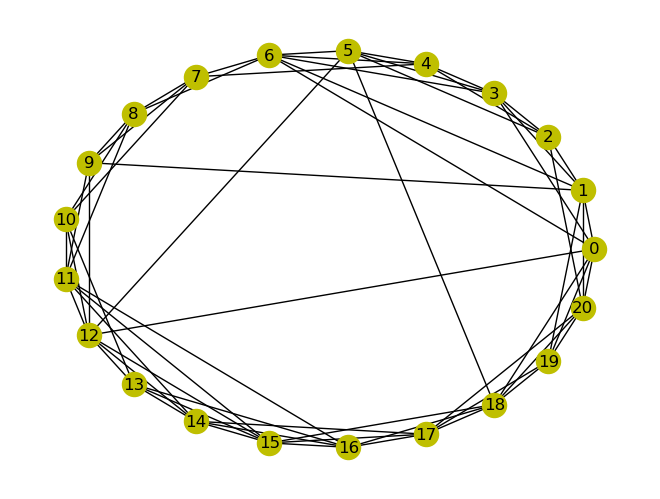

In [17]:
G = nx.watts_strogatz_graph(n, 2*d, 0.1)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))

0.4427437641723356
1.8952380952380952


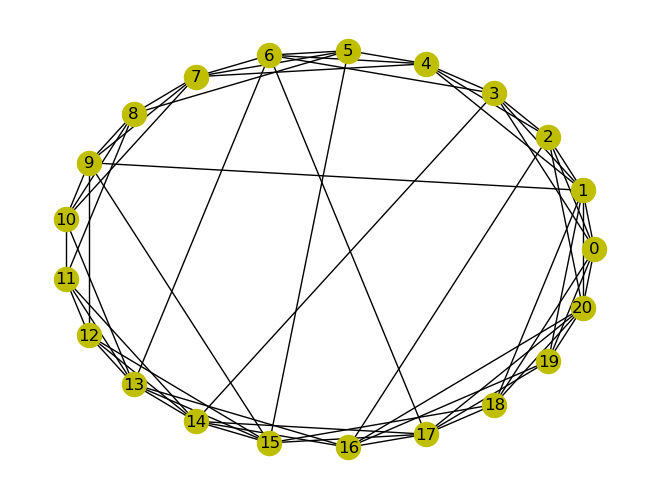

In [18]:
G = nx.watts_strogatz_graph(n, 2*d, 0.2)
nx.draw_circular(G, **opts)
print(nx.average_clustering(G))
print(nx.average_shortest_path_length(G))

## Properties of WS-Graphs

* The small-world attributes of a $(n, d, p)$-WS graph depend on the probability $p$.
The following measurements have been taken for $n = 1000$ and $d = 5$.

<table>
    <tr>
        <th>$p$</th>
        <th>$L$</th>
        <th>$C$</th>
    </tr>
    <tr>
        <td>$0$</td>
        <td>$50.5$</td>
        <td>$0.667$</td>
    </tr>
    <tr>
        <td>$0.01$</td>
        <td>$8.94$</td>
        <td>$0.648$</td>
    </tr>
    <tr>
        <td>$0.05$</td>
        <td>$5.26$</td>
        <td>$0.576$</td>
    </tr>
    <tr>
        <td>$1$</td>
        <td>$3.27$</td>
        <td>$0.00910$</td>
    </tr>
</table>

## Code Corner

### `random`

* `randint`: [[doc]](https://docs.python.org/2/library/random.html#random.randint) random integer

### `networkx`


* `cycle_graph`: [[doc]](https://networkx.github.io/documentation/networkx-1.9/reference/generated/networkx.generators.classic.cycle_graph.html)


* `circulant_graph`: [[doc]](https://networkx.github.io/documentation/stable/reference/generated/networkx.generators.classic.circulant_graph.html)


* `watts_strogatz_graph`: [[doc]](https://networkx.github.io/documentation/stable/reference/generated/networkx.generators.random_graphs.watts_strogatz_graph.html)


* `draw_circular`: [[doc]](https://networkx.github.io/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_circular.html)